In [82]:
# California Housing Price Prediction
## Prediction Data Analisis Project

#Dataset Description

This project analyzes housing data from the California Housing Dataset to understand the factors that influence house prices and to build a predictive model.

The dataset contains 20,640 observations, where each row represents a housing district in California. Each observation includes demographic, geographic, and housing-related variables that describe the characteristics of that district.

The main goal of the analysis is to predict the median house value using different explanatory variables in the way of exploring and understanding the structure of the California Housing Dataset.
This includes examining variables such as:

income levels

population

number of rooms

housing age

geographic location

The purpose is to understand how these factors describe housing districts.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This step imports the required Python libraries for the project. Pandas is used for data manipulation and analysis, NumPy supports numerical computations, Matplotlib and Seaborn are used for data visualization.

In [87]:
df = pd.read_csv("Califonia_Housing_Data.csv")
print(df.head())
print(df.tail())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms

The dataset is loaded from a CSV file using Pandas. The head() and tail() functions are used to display the first and last rows of the dataset to verify that the data has been loaded correctly and to obtain an initial overview of the dataset structure.

In [89]:
df.shape

(20640, 10)

The shape function is used to determine the size of the dataset. The dataset contains 20,640 rows and 10 columns, meaning there are 20,640 observations and 10 variables describing each housing district.

In [91]:
#1 understanding the data

In [92]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


The head() function displays the first five rows of the dataset. This helps understand the structure of the data, including the available features such as longitude, latitude, number of rooms, population, and median house value.

In [94]:
# Data Description

The statistical summary provides an overview of the numerical variables in the dataset.
    Key observations:
The dataset contains 20,640 observations
each row represents a housing district in California. 
Each observation includes demographic, geographic, and housing-related variables that describe the characteristics of that district.

In [95]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

This step lists all column names in the dataset. Understanding the available variables is important for identifying which features may influence housing prices.

In [97]:
# Load dataset
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

df.head()
print(df.tail())

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  Price  
20635    -121.09  0.781  
20636    -121.21  0.771  
20637    -121.22  0.923  
20638    -121.32  0.847  
20639    -121.24  0.894  


In [98]:
data.nunique()

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
dtype: int64

The nunique() function counts the number of unique values in each column. This helps identify categorical variables and understand the variability within each feature.

In [100]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

This step checks for missing values in each column of the dataset. The results show that there are no missing values in the dataset, meaning no additional data cleaning is required for missing data.

In [102]:
df = df.dropna()
df = df.drop_duplicates()

This step removes any potential missing values and duplicate rows from the dataset. Data cleaning ensures that the dataset is consistent and reliable for analysis and model training.

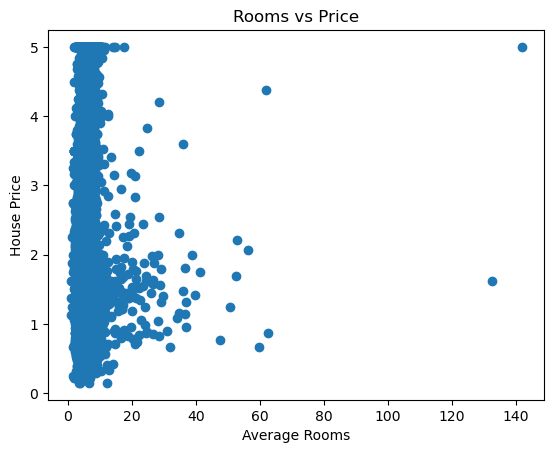

In [104]:
plt.scatter(df['AveRooms'], df['Price'])
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Rooms vs Price")
plt.show()

A scatter plot is used to visualize the relationship between the average number of rooms and housing prices. Each point represents a housing district. This visualization helps identify whether there is a correlation between the number of rooms and the price of houses.

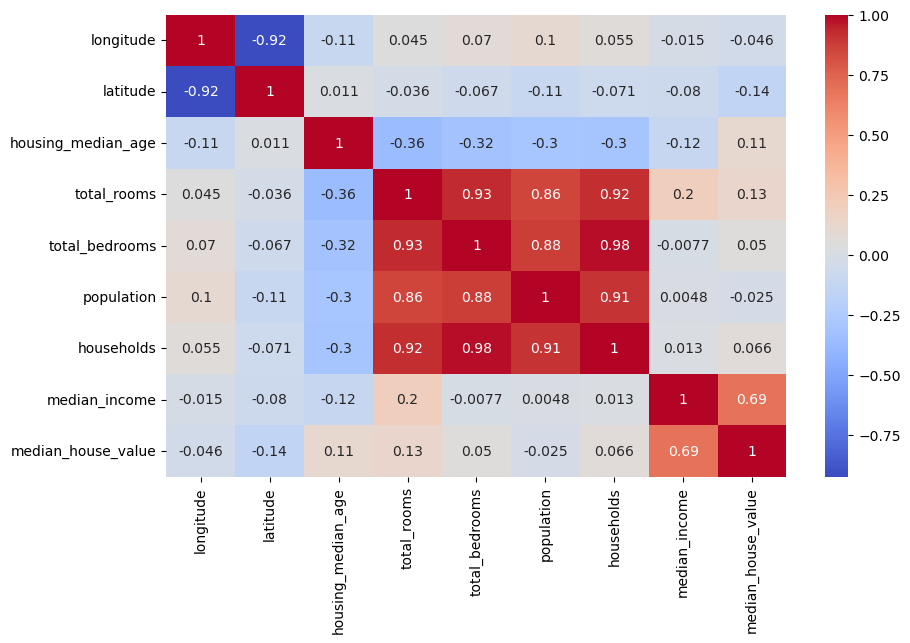

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap shows the strength and direction of relationships between numerical variables in the dataset. A higher correlation value indicates a stronger relationship between two variables. The heatmap helps identify which features are most related to housing prices.Median income appears to have the strongest positive correlation with house prices.

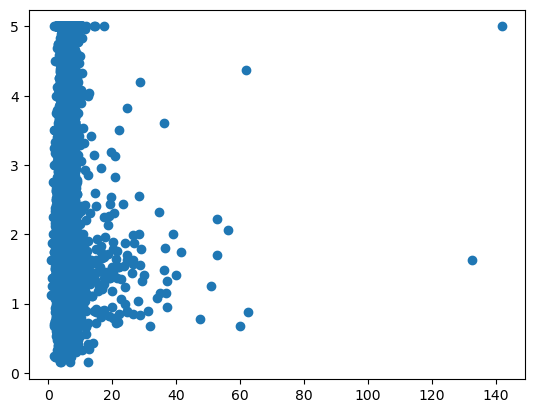

In [110]:
plt.scatter(df['AveRooms'], df['Price'])
plt.show()

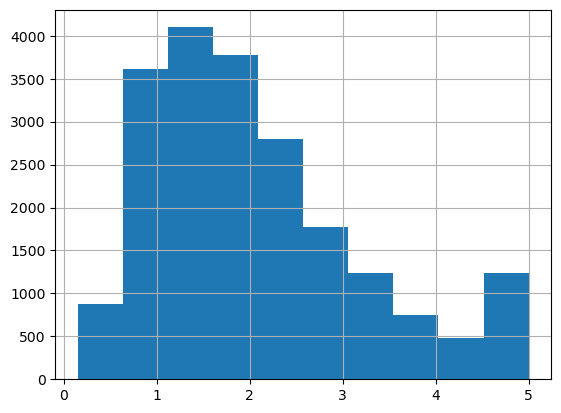

In [111]:
df['Price'].hist()
plt.show()

The histogram visualizes the distribution of housing prices in the dataset. It shows how frequently different price ranges occur and helps identify whether the data is normally distributed or skewed.

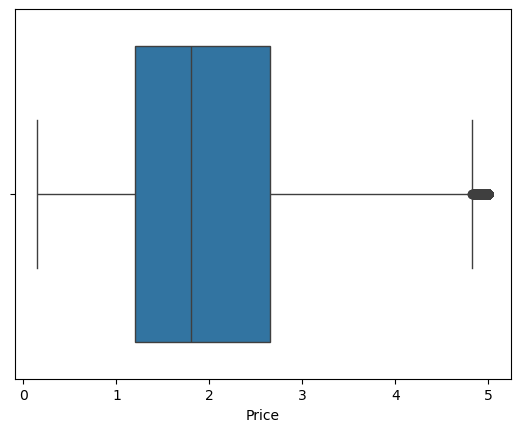

In [113]:
sns.boxplot(x=df['Price'])
plt.show()

The box plot is used to detect outliers and understand the spread of housing prices. It shows the median, quartiles, and extreme values in the dataset.

In [116]:
df['rooms_per_person'] = df['AveRooms'] / df['Population']

A new feature called rooms_per_person is created to represent the number of rooms available per person in a district. Feature engineering helps create new variables that may improve the performance of machine learning models.

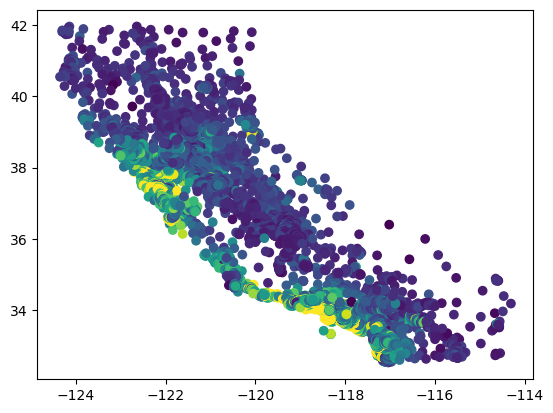

In [118]:
plt.scatter(df['Longitude'], df['Latitude'], c=df['Price'])

This scatter plot visualizes the geographic distribution of housing districts using longitude and latitude. The color of each point represents the house price, allowing us to observe how housing prices vary across different locations in California.

In [120]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is separated into predictor variables (X) and the target variable (y). The predictors contain housing features, while the target variable represents the housing price that the model will learn to predict

The dataset is split into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance.

In [123]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


A Linear Regression model is used to predict housing prices based on the input features. The model learns the relationship between the predictors and the target variable during the training phase.

In [125]:
y_pred = model.predict(X_test)

In [126]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.5555167248646335
R2: 0.5760737799504684


Model performance is evaluated using two metrics. Mean Squared Error (MSE) measures the average squared difference between predicted and actual prices, while the R² score indicates how well the model explains the variation in housing prices.

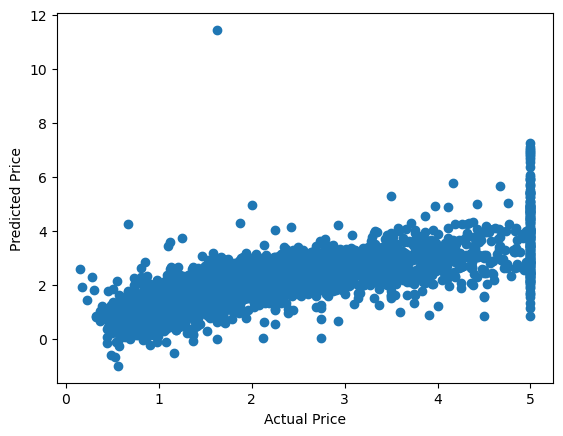

In [130]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

This scatter plot compares the actual housing prices with the predicted prices from the model. If the model performs well, the points should follow a diagonal pattern, indicating that predictions are close to the real values.

In [131]:
# Conclusion

This project analyzed the California Housing dataset and developed a machine learning model to predict housing prices. Exploratory data analysis showed that median income has the strongest relationship with housing prices. The linear regression model achieved moderate predictive performance, demonstrating that housing prices are influenced by several demographic and geographic factors.